In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from torchvision import models
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# === CONFIGURATION ===
class Config:
    OUTPUT_DIR = 'drive/MyDrive/working'
    BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_model_res18_20_ep.pt")

config = Config()

# === DATASET ===
class MFCCDataset(Dataset):
    def __init__(self, data_dict, label_dict):
        self.samples = list(data_dict.keys())
        self.data_dict = data_dict
        self.label_dict = label_dict

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        samplename = self.samples[idx]
        mfcc = self.data_dict[samplename]
        label = self.label_dict[samplename]
        mfcc_tensor = torch.tensor(mfcc, dtype=torch.float32).unsqueeze(0)
        label_tensor = torch.tensor(label, dtype=torch.long)
        return mfcc_tensor, label_tensor


# === Data loaders ===

def load_file(file):
    samplename = file.stem
    species_id = samplename.split("-")[0]

    # Just load the MFCC array
    mfcc = np.load(file,mmap_mode="r")  # <-- DIRECTLY load it, no librosa, no compute_mfcc

    return samplename, mfcc, species_id

def load_data_structure_parallel(root_dir, max_workers=4):
    loaded_data = {}
    sample_to_label = {}

    files = [file for class_dir in Path(root_dir).iterdir() if class_dir.is_dir()
             for file in class_dir.glob("*.npy")]

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_file = {executor.submit(load_file, file): file for file in files}
        for future in as_completed(future_to_file):
            samplename, mel_spec, species_id = future.result()
            loaded_data[samplename] = mel_spec
            sample_to_label[samplename] = species_id

    return loaded_data, sample_to_label

def prepare_dataloaders(data_dict, label_dict, batch_size, train_names=None, val_names=None, label_encoder=None):
    # Only keep samples that are present in both data_dict and label_dict
    available_samples = sorted(set(label_dict.keys()) & set(data_dict.keys()))

    if label_encoder is None:
        label_encoder = LabelEncoder()
        label_encoder.fit(list(label_dict.values()))

    sample_to_encoded = {
        sample_name: label_encoder.transform([label_dict[sample_name]])[0]
        for sample_name in available_samples
    }

    # If train/val names provided, filter them too
    if train_names is not None and val_names is not None:
        train_names = [k for k in train_names if k in data_dict]
        val_names = [k for k in val_names if k in data_dict]
    else:
        train_names, val_names = train_test_split(available_samples, test_size=0.2, random_state=42)

    # Final check — all names should be in data_dict and sample_to_encoded
    train_data = {k: data_dict[k] for k in train_names}
    val_data = {k: data_dict[k] for k in val_names}
    train_labels = {k: sample_to_encoded[k] for k in train_names}
    val_labels = {k: sample_to_encoded[k] for k in val_names}

    train_ds = MFCCDataset(train_data, train_labels)
    val_ds = MFCCDataset(val_data, val_labels)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size)

    return train_dl, val_dl, len(label_encoder.classes_), label_encoder




# === MODEL ===
class MelCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )
        self.adaptive_pool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

    def predict(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            return torch.argmax(logits, dim=1)


class MelResNetInference(nn.Module):
    def __init__(self, num_classes, backbone_name="resnet18"):
        super().__init__()

        # Choose backbone based on the name (no pretrained weights)
        if backbone_name == "resnet18":
            self.backbone = models.resnet18(weights=None)
        elif backbone_name == "resnet34":
            self.backbone = models.resnet34(weights=None)
        elif backbone_name == "resnet50":
            self.backbone = models.resnet50(weights=None)
        elif backbone_name == "resnet101":
            self.backbone = models.resnet101(weights=None)
        elif backbone_name == "resnet152":
            self.backbone = models.resnet152(weights=None)
        else:
            raise ValueError(f"Unknown backbone: {backbone_name}")

        # Adjust the first conv layer for 1-channel input
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # Replace the final fully connected layer
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

    def predict(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            return torch.argmax(logits, dim=1)

    @classmethod
    def load_from_checkpoint(cls, checkpoint_path, num_classes, backbone_name="resnet18"):
        model = cls(num_classes, backbone_name=backbone_name)
        model.load_state_dict(torch.load(checkpoint_path, map_location="cpu"))
        model.eval()
        return model

# === EVALUATION ===
def evaluate_roc_auc(model, dataloader, device, num_classes):
    model.eval()
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            probs = F.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_targets.append(y.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    y_true = label_binarize(all_targets, classes=np.arange(num_classes))
    scored_classes = np.where(y_true.sum(axis=0) > 0)[0]

    if len(scored_classes) == 0:
        return 0.0

    try:
        return roc_auc_score(y_true[:, scored_classes], all_probs[:, scored_classes], average="macro")
    except ValueError:
        return 0.0

# Calculate accuracies
def evaluate_accuracy(model, val_dl, device='cuda'):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in val_dl:
            inputs, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    acc = accuracy_score(all_labels.numpy(), all_preds.numpy())
    return acc

def evaluate_f1(model, dataloader, device):
    """
    Returns (macro_f1, weighted_f1) scores.
    """
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            preds = model.predict(x)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(y.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
    return macro_f1, weighted_f1


# This loads all the mel_spectrograms at once into memery need atleast 12 GB RAM

In [4]:
ROOT_DIR = Path("drive/MyDrive/working/mfccs")
loaded_bird_data, sample_to_label = load_data_structure_parallel(ROOT_DIR)

# Load saved splits
train_names = np.load(os.path.join(config.OUTPUT_DIR, "train_names.npy"), allow_pickle=True).tolist()
val_names = np.load(os.path.join(config.OUTPUT_DIR, "val_names.npy"), allow_pickle=True).tolist()

# Load label encoder
label_encoder = joblib.load(os.path.join(config.OUTPUT_DIR, "label_encoder (1).pkl"))
print("✅ Loaded LabelEncoder.")

# Pass them in
train_dl, val_dl, num_classes, label_encoder = prepare_dataloaders(
    loaded_bird_data, sample_to_label, batch_size=32,
    train_names=train_names, val_names=val_names, label_encoder=label_encoder
)

✅ Loaded LabelEncoder.


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [5]:
def load_and_compare_val_dl(val_dl, save_dir):
    load_path = os.path.join(save_dir, "val_dl_full.npz")
    data = np.load(load_path, allow_pickle=True)

    saved_sample_names = data['sample_names'].tolist()
    saved_labels = data['labels']

    current_sample_names = val_dl.dataset.samples
    current_labels = np.array([label.item() for _, label in val_dl.dataset])

    # Compare sample names
    if saved_sample_names != current_sample_names:
        print("❌ Sample names mismatch!")
    else:
        print("✅ Sample names match.")

    # Compare labels
    if not np.array_equal(saved_labels, current_labels):
        print("❌ Labels mismatch!")
    else:
        print("✅ Labels match.")


load_and_compare_val_dl(val_dl, config.OUTPUT_DIR)


❌ Sample names mismatch!
❌ Labels mismatch!


# Loads models and gets ROC-AUC score for each

In [6]:
# # Paths to your saved best models
# checkpoint_paths = {
#     "resnet18": "working/best_model_res18_label_fix.pt",
#     "resnet50": "working/best_model_res50_label_fix.pt",
#     "resnet101": "working/best_model_res101_label_fix.pt",
#     "alexnet": "working/best_model_alex1_label_fix.pt",
# }

# # Device
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Load models properly
# model_res18_load = MelResNetInference.load_from_checkpoint(
#     checkpoint_path=checkpoint_paths["resnet18"],
#     num_classes=num_classes,
#     backbone_name="resnet18"
# )

# model_res50_load = MelResNetInference.load_from_checkpoint(
#     checkpoint_path=checkpoint_paths["resnet50"],
#     num_classes=num_classes,
#     backbone_name="resnet50"
# )

# model_res101_load = MelResNetInference.load_from_checkpoint(
#     checkpoint_path=checkpoint_paths["resnet101"],
#     num_classes=num_classes,
#     backbone_name="resnet101"
# )

# # AlexNet-style CNN loading (separate because it’s not ResNet)
# model_alex_1_load = MelCNN(num_classes)
# model_alex_1_load.load_state_dict(torch.load(checkpoint_paths["alexnet"], map_location="cpu"))
# model_alex_1_load.eval()

# # Move models to device
# model_res18_load = model_res18_load.to(device)
# model_res50_load = model_res50_load.to(device)
# model_res101_load = model_res101_load.to(device)
# model_alex_1_load = model_alex_1_load.to(device)
import torch

# Paths to your saved best models
checkpoint_paths = {
    "resnet18": "drive/MyDrive/working/best_model_res18_20_ep.pt",
    #"resnet50": "working/best_model_res50_20_ep.pt",
    #"resnet101": "working/best_model_res101_20_ep.pt",
    #"alexnet": "working/best_model_alex1_20_ep.pt",
    # New ones you trained:
    #"resnet18_focal": "working/best_model_res18_focal_not_weighted.pt",
}

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load models properly
model_res18_load = MelResNetInference.load_from_checkpoint(
    checkpoint_path=checkpoint_paths["resnet18"],
    num_classes=num_classes,
    backbone_name="resnet18"
)

"""model_res50_load = MelResNetInference.load_from_checkpoint(
    checkpoint_path=checkpoint_paths["resnet50"],
    num_classes=num_classes,
    backbone_name="resnet50"
)

model_res101_load = MelResNetInference.load_from_checkpoint(
    checkpoint_path=checkpoint_paths["resnet101"],
    num_classes=num_classes,
    backbone_name="resnet101"
)

# AlexNet-style CNN loading (separate because it’s not ResNet)
model_alex_1_load = MelCNN(num_classes)
model_alex_1_load.load_state_dict(torch.load(checkpoint_paths["alexnet"], map_location="cpu"))
model_alex_1_load.eval()

model_res18_focal_load = MelResNetInference.load_from_checkpoint(
    checkpoint_path=checkpoint_paths["resnet18_focal"],
    num_classes=num_classes,
    backbone_name="resnet18"
)
"""

# Move all models to device
model_res18_load = model_res18_load.to(device)
#model_res50_load = model_res50_load.to(device)
#model_res101_load = model_res101_load.to(device)
#model_alex_1_load = model_alex_1_load.to(device)
#model_res18_focal_load = model_res18_focal_load.to(device)


# Eval

In [7]:
# Group models
models = {
    #"ResNet50": model_res50_load,
    #"ResNet101": model_res101_load,
    #"AlexNet": model_alex_1_load,
    "ResNet18 (CrossEntropy)": model_res18_load,
    #"ResNet18 (Focal loss)": model_res18_focal_load,
}


# Collect results into a list
results = []

print("Model Validation Metrics (ROC AUC, Accuracy, F1 Macro, F1 Weighted):")
for model_name, model in models.items():
    roc_auc = evaluate_roc_auc(model, val_dl, device, num_classes)
    acc = evaluate_accuracy(model, val_dl, device)
    macro_f1, weighted_f1 = evaluate_f1(model, val_dl, device)

    results.append({
        "Model": model_name,
        "ROC AUC": roc_auc,
        "Accuracy": acc,
        "F1 Macro": macro_f1,
        "F1 Weighted": weighted_f1
    })

    print(f"{model_name}: ROC AUC = {roc_auc:.4f} | Accuracy = {acc:.4f} | F1 Macro = {macro_f1:.4f} | F1 Weighted = {weighted_f1:.4f}")

# Create DataFrame
results_df = pd.DataFrame(results)


Model Validation Metrics (ROC AUC, Accuracy, F1 Macro, F1 Weighted):
ResNet18 (CrossEntropy): ROC AUC = 0.9621 | Accuracy = 0.6156 | F1 Macro = 0.4172 | F1 Weighted = 0.6012


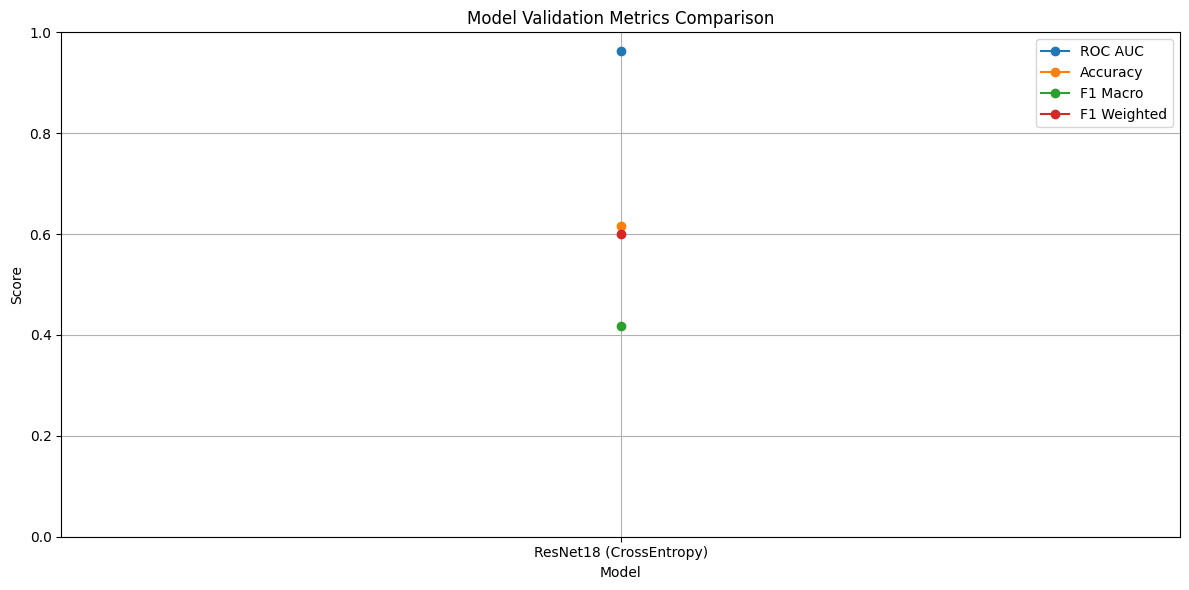

In [8]:
# Plot
metrics = ["ROC AUC", "Accuracy", "F1 Macro", "F1 Weighted"]
fig, ax = plt.subplots(figsize=(12, 6))

for metric in metrics:
    ax.plot(results_df["Model"], results_df[metric], marker="o", label=metric)

ax.set_title("Model Validation Metrics Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0.0, 1.0)
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch

def plot_confusion_matrix_top_classes(
    model,
    val_dl,
    num_classes,
    device,
    label_encoder,
    taxonomy_path="drive/MyDrive/working/taxonomy.csv",
    top_n=5,
    bottom_n=None,
    custom_title=None  # <-- new parameter
):
    """
    Predicts on val_dl, builds confusion matrix, and plots top-N or bottom-N classes using scientific names.
    """
    # Load taxonomy and build mapping
    taxonomy_df = pd.read_csv(taxonomy_path)
    label_to_sci = dict(zip(taxonomy_df["primary_label"], taxonomy_df["scientific_name"]))

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for mel_batch, label_batch in val_dl:
            mel_batch = mel_batch.to(device)
            preds = model.predict(mel_batch)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(label_batch.numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    cm = confusion_matrix(all_labels, all_preds, labels=np.arange(num_classes))
    cm_norm = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-6)

    class_counts = np.bincount(all_labels, minlength=num_classes)
    valid_classes = np.where(class_counts > 0)[0]

    if bottom_n is not None:
        sorted_valid = np.argsort(class_counts[valid_classes])
        selected_classes = valid_classes[sorted_valid[:bottom_n]]
        title_suffix = f"Bottom {bottom_n} Classes (with at least 1 sample)"
    else:
        sorted_valid = np.argsort(class_counts[valid_classes])
        selected_classes = valid_classes[sorted_valid[-top_n:]]
        title_suffix = f"Top {top_n} Classes"

    cm_selected = cm_norm[np.ix_(selected_classes, selected_classes)]

    # Use scientific names
    selected_primary_labels = [label_encoder.inverse_transform([i])[0] for i in selected_classes]
    selected_class_labels = [label_to_sci.get(lbl, lbl) for lbl in selected_primary_labels]

    # Plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_selected, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=selected_class_labels, yticklabels=selected_class_labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    final_title = custom_title if custom_title else f"Normalized Confusion Matrix ({title_suffix})"
    plt.title(final_title)
    plt.tight_layout()
    plt.show()

Plotting confusion matrix for: ResNet18 (CrossEntropy)


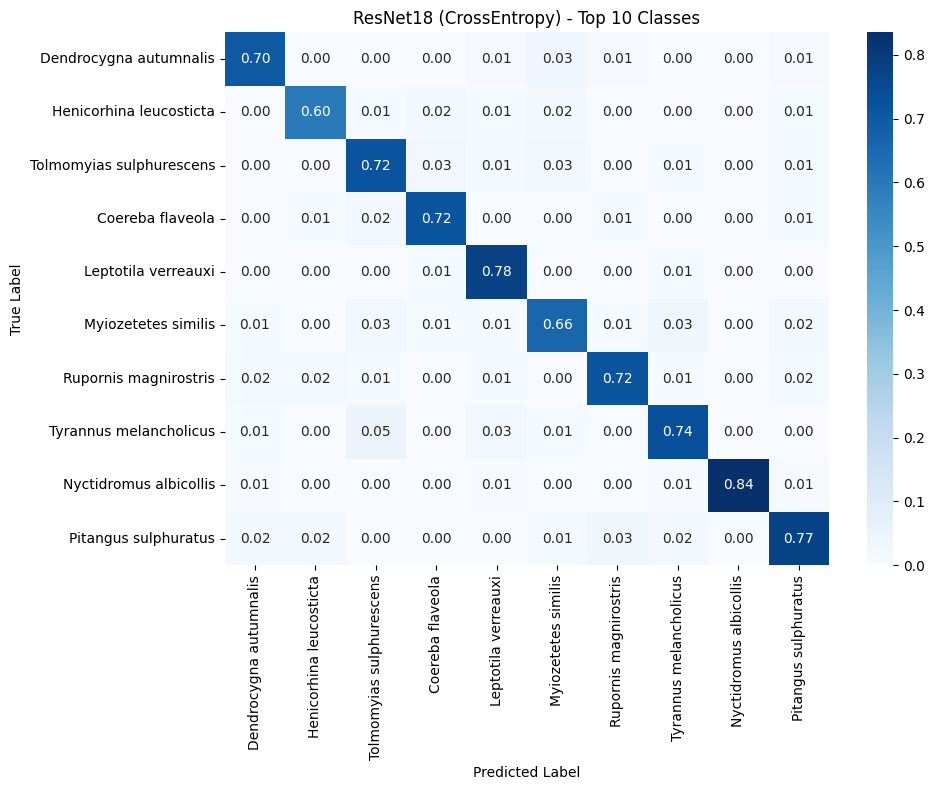

In [13]:
model_dict = {
    "ResNet18 (CrossEntropy)": model_res18_load,
}

for name, model in model_dict.items():
    print(f"Plotting confusion matrix for: {name}")
    plot_confusion_matrix_top_classes(
        model=model,
        val_dl=val_dl,
        num_classes=num_classes,
        device=device,
        label_encoder=label_encoder,
        top_n=10,
        custom_title=f"{name} - Top 10 Classes"
    )

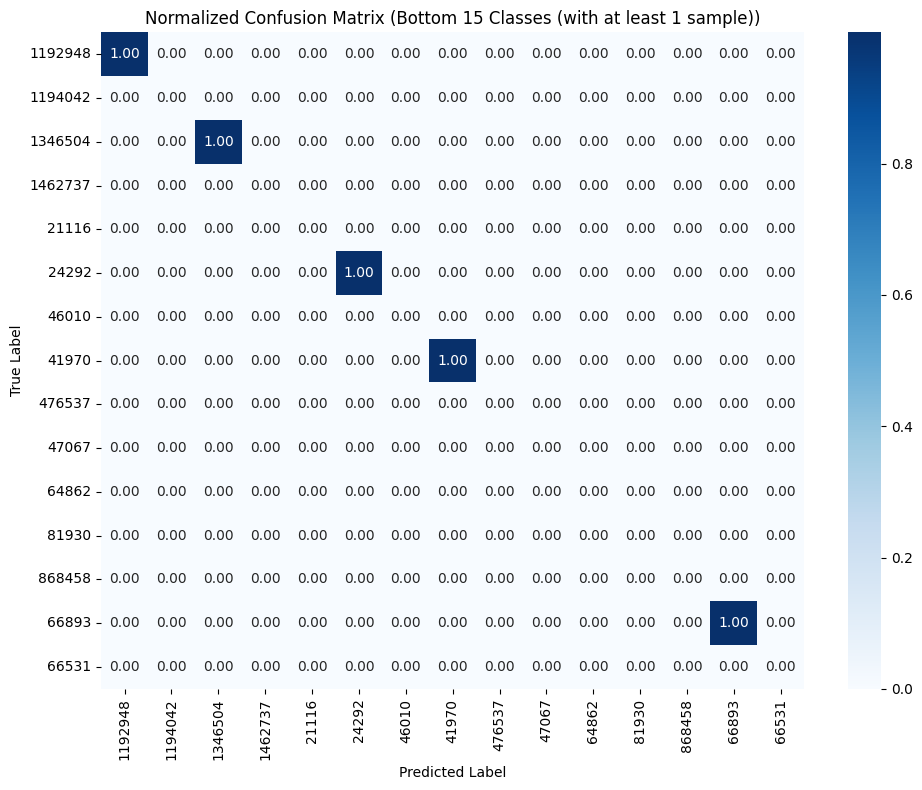

In [ ]:
plot_confusion_matrix_top_classes(
    model_res18_load,
    val_dl,
    num_classes,
    device,
    label_encoder=label_encoder,
    bottom_n=15,
    show_labels=True  # ❌ No labels (too many classes)
)

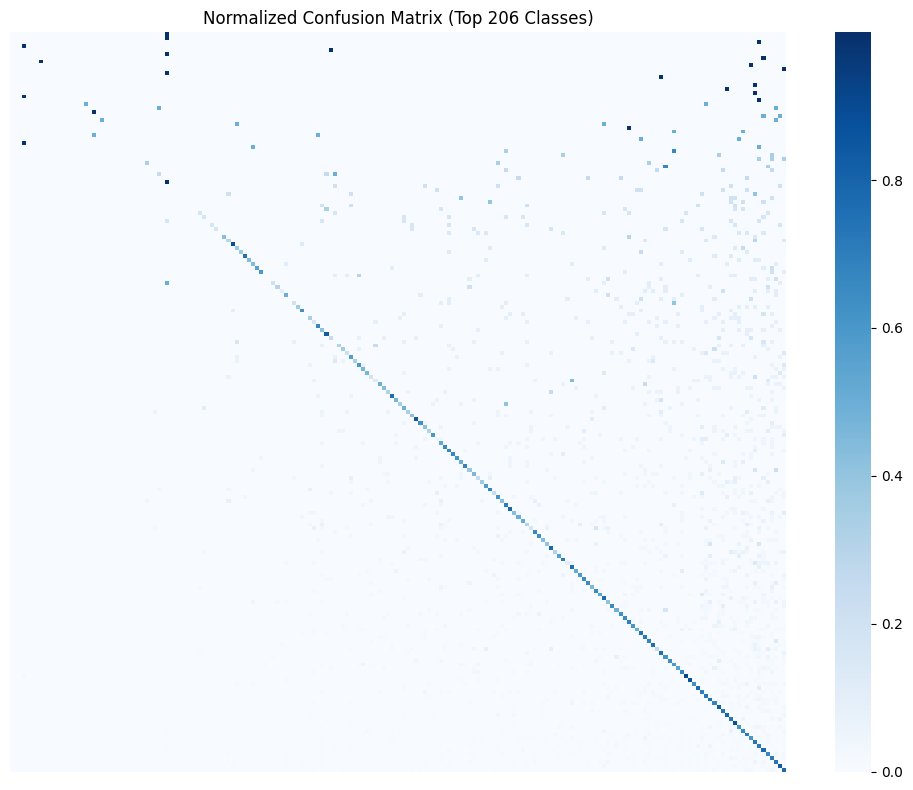

In [11]:
plot_confusion_matrix_top_classes(
    model_res18_load,
    val_dl,
    num_classes,
    device,
    label_encoder=label_encoder,
    top_n=206,
    show_labels=False  # ❌ No labels (too many classes)
)